# Taller 1: Sistemas de ecuaciones, matrices y determinantes

Este taller integra los tres temas vistos hasta ahora: sistemas de ecuaciones lineales,
operaciones con matrices y determinantes.

**Importante:** resuelve primero cada ejercicio a **lápiz y papel** (eliminación
gaussiana, operaciones matriciales, expansión por cofactores, etc.). Usa `sympy`
únicamente para **corroborar** tus resultados, no para reemplazarlos.

Trabajaremos con `sympy` para manipular matrices y sistemas de forma **simbólica y
exacta** (sin errores de redondeo).

In [1]:
from sympy import Matrix, Rational, symbols, linsolve, eye, init_printing
init_printing()

## Parte 1 — Sistemas de ecuaciones lineales

### Ejercicio 1 — Eliminación gaussiana

Considera el sistema:

$$
\begin{aligned}
x + 2y - z &= 3 \\
2x - y + 3z &= 7 \\
-x + 3y + 2z &= 0
\end{aligned}
$$

1. Escribe la matriz aumentada $[A \mid b]$.
2. Resuelve el sistema por eliminación gaussiana (a mano), mostrando las operaciones
   entre filas que usaste.
3. Corrobora el resultado con `sympy`, usando `Matrix.rref()` sobre la matriz aumentada
   o `linsolve`.
4. Hallar la factorización $LU$ de la matriz de coeficientes

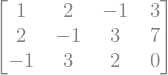

In [2]:
# Ejercicio 1: construye la matriz aumentada [A | b] con Matrix([[1, 2, -1, 3], ...])
# y calcula su forma escalonada reducida con .rref()
A = Matrix([[1,2,-1,3], [2, -1, 3, 7], [-1, 3, 2, 0]])
A

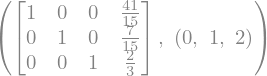

In [3]:
A.rref()

In [6]:
B = A[:, :-1].copy()

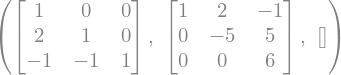

In [9]:
B.LUdecomposition()

### Ejercicio 2 — Sistemas con infinitas soluciones o sin solución

Considera los dos sistemas siguientes.

**Sistema A:**
$$
\begin{aligned}
x + y + z &= 6 \\
2x + 2y + 2z &= 12 \\
x - y + 2z &= 5
\end{aligned}
$$

**Sistema B:**
$$
\begin{aligned}
x + y + z &= 6 \\
2x + 2y + 2z &= 10 \\
x - y + 2z &= 5
\end{aligned}
$$

1. Para cada sistema, calcula el `rref` de la matriz aumentada y clasifícalo como
   **consistente con solución única**, **consistente con infinitas soluciones**, o
   **inconsistente**.
2. Si el sistema tiene infinitas soluciones, exprésalas en términos de un parámetro
   libre.
3. Explica, a partir del `rref`, cómo se reconoce cada uno de los tres casos.

In [ ]:
# Ejercicio 2: construye la matriz aumentada de cada sistema y calcula .rref()
# analiza el numero de pivotes vs el numero de incognitas para clasificar cada caso

### Ejercicio 3 — Sistema con parámetro

Considera el sistema, donde $k$ es un parámetro real:

$$
\begin{aligned}
x + y + kz &= 2 \\
x + k y + z &= 2 \\
k x + y + z &= 2
\end{aligned}
$$

1. ¿Para qué valores de $k$ el sistema tiene solución única? (Pista: relaciona esto con
   el determinante de la matriz de coeficientes.)
2. Usa `sympy` con `k = symbols('k')` para calcular el determinante de la matriz de
   coeficientes en función de $k$, y factorízalo con `.factor()`.
3. Para uno de los valores de $k$ donde el sistema **no** tiene solución única, sustituye
   ese valor y determina si el sistema resultante es inconsistente o tiene infinitas
   soluciones.

In [ ]:
# Ejercicio 3: define k = symbols('k'), construye la matriz de coeficientes A(k)
# y calcula A.det().factor(); luego sustituye un valor critico de k con A.subs(k, valor)

## Parte 2 — Matrices

### Ejercicio 4 — Operaciones básicas

Sean:

$$
A = \left[\begin{array}{rrr} 2 & 0 & 1 \\ -1 & 3 & 2 \\ 1 & 1 & 0 \end{array}\right], \qquad
B = \left[\begin{array}{rrr} 1 & 2 & -1 \\ 0 & 1 & 3 \\ 2 & -1 & 1 \end{array}\right]
$$

Calcula, a mano y luego con `sympy`:

1. $A + B$ y $A - 2B$.
2. $AB$ y $BA$. ¿Son iguales? ¿Qué te dice esto sobre la multiplicación de matrices?
3. $A^T$ y $(AB)^T$. Verifica que $(AB)^T = B^T A^T$.

In [ ]:
# Ejercicio 4: define A y B con Matrix([...]) y calcula A + B, A - 2*B, A*B, B*A,
# A.T, (A*B).T y B.T * A.T para comparar

### Ejercicio 5 — Matriz inversa

Usa la matriz $A$ del Ejercicio 4.

1. Calcula $\det(A)$. ¿Es invertible $A$?
2. Calcula $A^{-1}$ (a mano, por Gauss-Jordan; corrobora con `A.inv()` o
   `A**-1`).
3. Verifica que $A A^{-1} = I$ y $A^{-1} A = I$.
4. Usa $A^{-1}$ para resolver el sistema $Ax = b$ con $b = (1, 2, 0)^T$, mediante
   $x = A^{-1} b$.

In [ ]:
# Ejercicio 5: calcula A.det(), A.inv(), A.inv() * A, A * A.inv()
# y luego x = A.inv() * Matrix([1, 2, 0])

### Ejercicio 6 — Matrices especiales y rango

1. Construye la matriz identidad $I_4$ y una matriz diagonal $D$ con entradas
   $2, -1, 3, 0$ en la diagonal.
2. Calcula $\det(D)$ sin expandir nada, solo observando su estructura. Explica por qué
   el resultado era predecible.
3. Calcula el rango (`.rank()`) de $D$. ¿Por qué el rango es menor que 4?
4. Construye una matriz $C$ de $3\times 3$ en la que la tercera fila sea combinación
   lineal de las dos primeras, y calcula su rango y su determinante. ¿Qué relación
   observas entre ambos?

In [ ]:
# Ejercicio 6: usa eye(4), diag(2, -1, 3, 0), .rank() y construye C con una fila dependiente
# de las otras dos para comparar C.rank() con C.det()

## Parte 3 — Determinantes

### Ejercicio 7 — Cofactores y propiedades

Sea:

$$
A = \left[\begin{array}{rrr} 1 & 2 & 3 \\ 0 & -1 & 4 \\ 2 & 1 & 5 \end{array}\right]
$$

1. Calcula $\det(A)$ por expansión de cofactores a lo largo de la primera fila (a mano).
2. Corrobora con `A.det()`.
3. Sea $A'$ la matriz que resulta de intercambiar las filas 1 y 2 de $A$. Sin volver a
   expandir cofactores, predice $\det(A')$ y verifica con `sympy`.
4. Sea $A''$ la matriz que resulta de sumarle a la fila 3 el doble de la fila 1. Predice
   $\det(A'')$ y verifica.

In [ ]:
# Ejercicio 7: define A, calcula A.det(); luego construye A' intercambiando filas
# (A.elementary_row_op / o reconstruyendo la matriz) y A'' sumando 2*fila1 a fila3,
# y compara sus determinantes con el de A

### Ejercicio 8 — Área y volumen

1. Los vectores $u = (4, 1)$ y $v = (1, 3)$ definen un paralelogramo en el plano.
   Calcula su área usando el determinante de la matriz $2\times 2$ formada por $u$ y
   $v$.
2. Los vectores $u = (1, 0, 2)$, $v = (0, 1, 1)$ y $w = (2, 1, 0)$ definen un
   paralelepípedo en $\mathbb{R}^3$. Calcula su volumen con el determinante de la
   matriz $3\times 3$ correspondiente.
3. En el caso 3D, ¿qué significaría que el determinante diera 0? Da una interpretación
   geométrica.

In [ ]:
# Ejercicio 8: construye la matriz 2x2 con u y v como filas (o columnas) y calcula abs(det)
# luego la matriz 3x3 con u, v, w y calcula abs(det) para el volumen

### Ejercicio 9 — Integrador: sistema, matriz y determinante

Una empresa produce tres mezclas químicas ($M_1, M_2, M_3$) combinando tres componentes
base ($C_1, C_2, C_3$). La matriz $A$ da la cantidad (en litros) de cada componente que
se necesita para producir una unidad de cada mezcla (columnas: mezclas; filas:
componentes):

$$
A = \begin{bmatrix}
1 & 2 & 1 \\
2 & 1 & 3 \\
1 & 1 & 2
\end{bmatrix}
$$

Esta semana se dispone de 90 litros de $C_1$, 130 litros de $C_2$ y 80 litros de $C_3$,
y se quiere usar **exactamente** todo el inventario.

1. Plantea el sistema $Ax = b$ donde $x = (x_1, x_2, x_3)^T$ son las unidades a producir
   de cada mezcla y $b$ es el vector de inventario disponible.
2. Calcula $\det(A)$. ¿Garantiza esto que el sistema tiene solución única?
3. Resuelve el sistema de dos formas distintas y verifica que coinciden:
   - Usando $x = A^{-1} b$.
   - Usando eliminación gaussiana sobre la matriz aumentada (`rref`).
4. Si en vez de querer usar todo el inventario exacto se buscara la combinación que
   *maximiza* el uso de $C_1$, ¿seguiría siendo suficiente resolver un sistema de
   ecuaciones? Explica brevemente por qué sí o por qué no.

In [ ]:
# Ejercicio 9: define A y b = Matrix([90, 130, 80]); calcula A.det();
# resuelve con A.inv() * b y tambien con el rref de la matriz aumentada [A | b]

## Para discutir

- ¿Qué relación hay entre que un sistema $Ax = b$ tenga solución única, que $A$ sea
  invertible, y que $\det(A) \neq 0$?
- Cuando un sistema tiene infinitas soluciones o ninguna, ¿qué le pasa al determinante
  de la matriz de coeficientes? ¿Y al rango de la matriz aumentada comparado con el
  rango de $A$?
- ¿Por qué en la práctica (por ejemplo, con matrices muy grandes) casi nunca se resuelve
  $Ax = b$ calculando $A^{-1}$ explícitamente, aunque matemáticamente sea válido?